# 머신러닝 기초 프로젝트 최종과제

**성명:** AX_jungeun  
**제출 파일:** `머신러닝_최종과제_AX_jungeun.ipynb`  
**마감:** 2026-09-08 00:00 KST (9월 7일 종료 시점)  
**원본 데이터:** Notion 과제 페이지의 `diabetes.csv`

이 노트북은 EDA와 전처리, 회귀·분류 학습, 과적합 진단과 개선, Hugging Face Gemma 기반 Few-shot 뉴스 분류를 한 번에 재현합니다.

## TL;DR

- 데이터는 **768행 × 9열**이며, 양성 비율은 **34.9%**입니다.
- 생리적으로 0이 될 수 없는 열의 0값은 중앙값 대체 대상으로 처리했습니다. 특히 `Insulin` 374건, `SkinThickness` 227건이 많습니다.
- 분류 기본 트리는 학습 정확도 **1.000**로 과적합을 보였고, 규제·교차검증·튜닝 후 테스트 F1은 **0.739**입니다.
- 회귀에서는 `Glucose`를 연속형 목표로 정의했습니다. Ridge 튜닝 후 테스트 MSE는 **649.59**, $R^2$는 **0.297**입니다.
- Gemma 3 270M의 생성 조건을 바꾸어 뉴스 분류 정확도와 반복 일관성을 비교합니다. 270M 모델의 결과는 성능 자랑이 아니라 **실험 설계와 해석 능력**을 보여주는 근거로 사용합니다.

## Context & Methods

### 핵심 가정

1. `Outcome`(0/1)은 분류 목표입니다.
2. 회귀 과제를 같은 데이터로 수행하기 위해 임상적으로 연속형인 `Glucose`를 회귀 목표로 정했습니다. 이때 `Outcome`과 `Glucose`는 입력 특성에서 제외하여 직접적인 목표 누수를 막았습니다.
3. `Pregnancies=0`은 유효할 수 있지만 `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`의 0은 생리학적 결측으로 취급합니다.
4. 데이터 분할 후 학습 데이터에만 결측치 대체·스케일링·인코딩을 적합하여 데이터 누수를 방지합니다.
5. `AgeGroup`을 파생 범주형 변수로 만들고 One-Hot Encoding을 적용해 범주형 처리 능력을 명시적으로 확인합니다.
6. 모든 난수 시드는 42로 고정합니다.

In [1]:
from pathlib import Path
import hashlib
import json
import os
import platform
import re
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_squared_error,
    r2_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

print({
    "python": platform.python_version(),
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "matplotlib": plt.matplotlib.__version__,
    "scikit-learn": sklearn.__version__,
})

{'python': '3.13.15', 'pandas': '3.0.5', 'numpy': '2.5.2', 'matplotlib': '3.11.1', 'scikit-learn': '1.9.0'}


## 1. 탐색적 데이터 분석(EDA) 및 전처리 파이프라인 구현

### 1-1. 데이터 구조 탐색 및 기초 분석

In [2]:
data_path = Path("diabetes.csv")
if not data_path.exists():
    raise FileNotFoundError("노트북과 같은 폴더에 diabetes.csv를 두고 다시 실행하세요.")

expected_sha256 = "698c203a14aa31941d2251175330c9199f3ccdb31597abbba2a3e35416257a72"
actual_sha256 = hashlib.sha256(data_path.read_bytes()).hexdigest()
assert actual_sha256 == expected_sha256, "제공된 원본 diabetes.csv와 체크섬이 다릅니다."

df = pd.read_csv(data_path)
print(f"shape = {df.shape}")
print(f"duplicates = {df.duplicated().sum()}")
print(f"sha256 = {actual_sha256}")
display(df.head())

shape = (768, 9)
duplicates = 0
sha256 = 698c203a14aa31941d2251175330c9199f3ccdb31597abbba2a3e35416257a72


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
structure_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "unique": df.nunique(),
})
display(structure_summary)
display(df.describe().T)

,dtype,missing,unique
Pregnancies,int64,0,17
Glucose,int64,0,136
BloodPressure,int64,0,47
SkinThickness,int64,0,51
Insulin,int64,0,186
BMI,float64,0,248
DiabetesPedigreeFunction,float64,0,517
Age,int64,0,52
Outcome,int64,0,2


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [4]:
zero_as_missing_columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
zero_summary = pd.DataFrame({
    "zero_count": df[zero_as_missing_columns].eq(0).sum(),
    "zero_rate": df[zero_as_missing_columns].eq(0).mean(),
}).sort_values("zero_rate", ascending=False)

def iqr_outlier_summary(frame):
    rows = []
    for column in frame.select_dtypes(include=np.number).columns:
        q1, q3 = frame[column].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        count = ((frame[column] < lower) | (frame[column] > upper)).sum()
        rows.append({"column": column, "iqr_outliers": int(count), "lower": lower, "upper": upper})
    return pd.DataFrame(rows).set_index("column").sort_values("iqr_outliers", ascending=False)

display(zero_summary)
display(iqr_outlier_summary(df))

,zero_count,zero_rate
Insulin,374,0.486979
SkinThickness,227,0.295573
BloodPressure,35,0.045573
BMI,11,0.014323
Glucose,5,0.006510


,iqr_outliers,lower,upper
column,,,
BloodPressure,45,35.000,107.000
Insulin,34,-190.875,318.125
DiabetesPedigreeFunction,29,-0.330,1.200
BMI,19,13.350,50.550
Age,9,-1.500,66.500
Glucose,5,37.125,202.125
Pregnancies,4,-6.500,13.500
SkinThickness,1,-48.000,80.000
Outcome,0,-1.500,2.500


### 1-2. 데이터 시각화 및 인사이트 도출

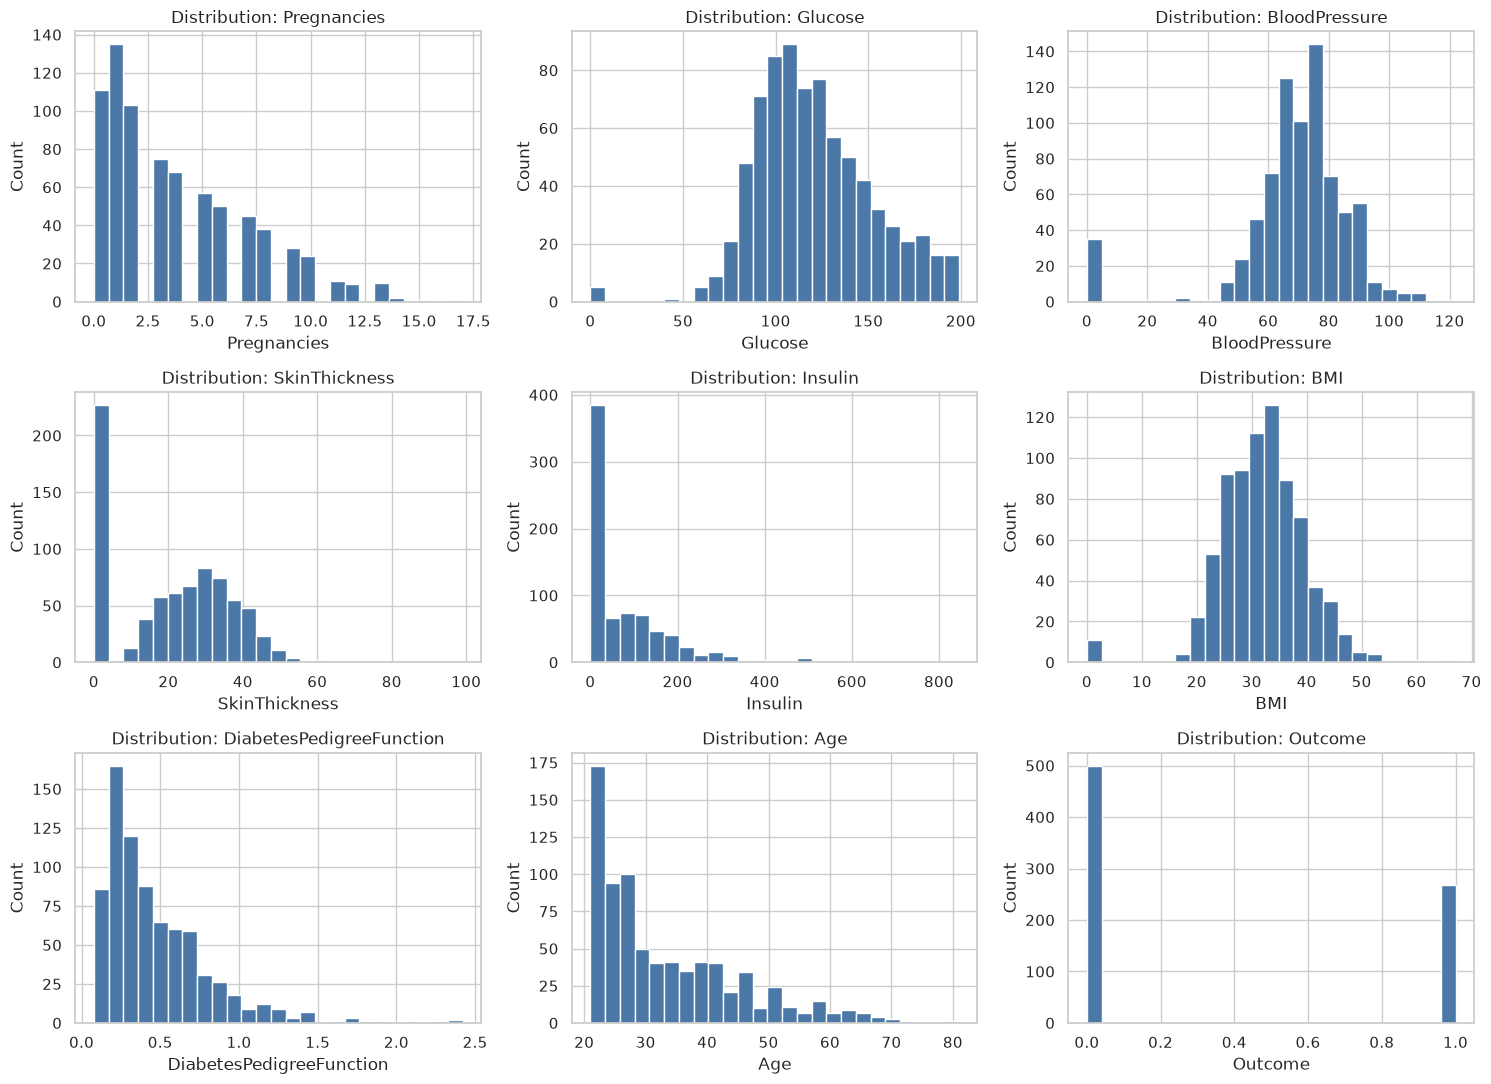

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for column, ax in zip(df.columns, axes.flat):
    ax.hist(df[column], bins=25, color="#4C78A8", edgecolor="white")
    ax.set_title(f"Distribution: {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

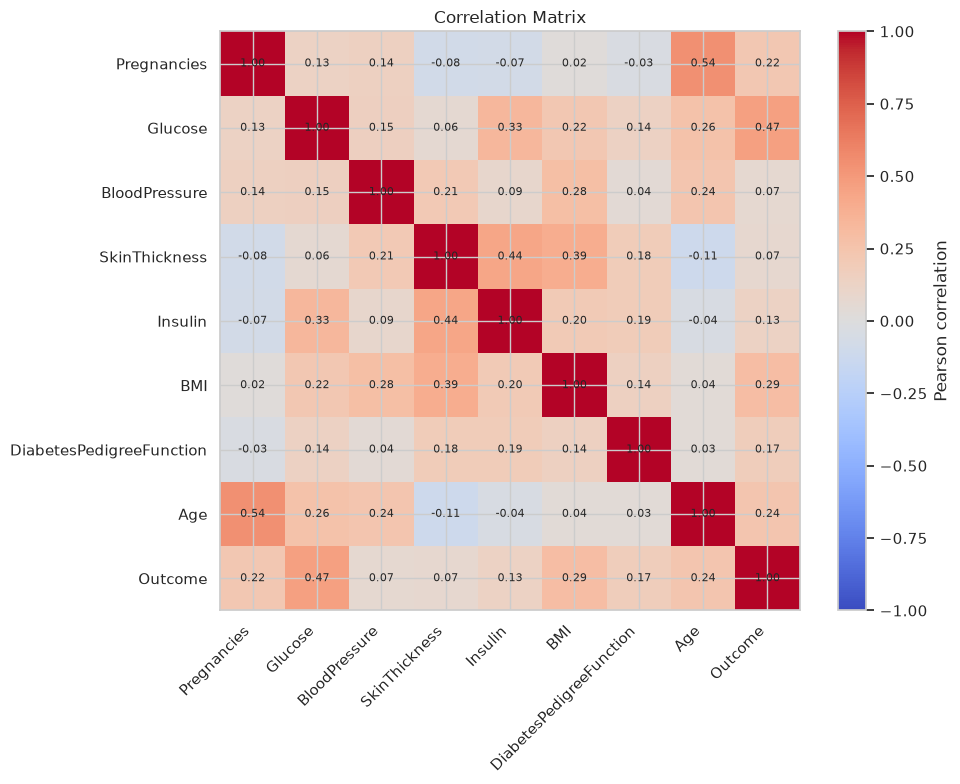

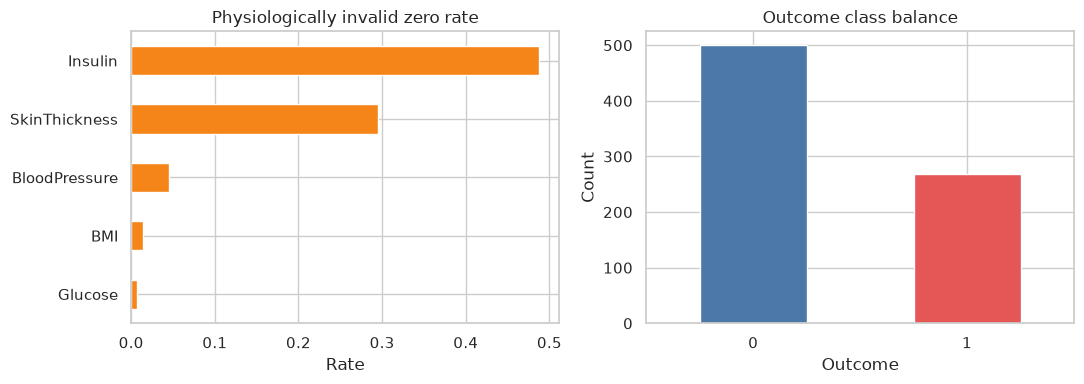

In [6]:
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.index)), corr.index)
for row in range(len(corr.index)):
    for col in range(len(corr.columns)):
        ax.text(col, row, f"{corr.iloc[row, col]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(image, ax=ax, label="Pearson correlation")
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
zero_summary["zero_rate"].sort_values().plot.barh(ax=axes[0], color="#F58518")
axes[0].set_title("Physiologically invalid zero rate")
axes[0].set_xlabel("Rate")
df["Outcome"].value_counts().sort_index().plot.bar(ax=axes[1], color=["#4C78A8", "#E45756"])
axes[1].set_title("Outcome class balance")
axes[1].set_xlabel("Outcome")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

### EDA 해석

- 원본에는 형식상 `NaN`이 없지만, 생리적으로 불가능한 0이 `Insulin` **374건(48.7%)**, `SkinThickness` **227건(29.6%)** 존재합니다. 따라서 단순히 “결측치 없음”으로 결론 내리면 안 됩니다.
- `Outcome=1`은 **268건**, `Outcome=0`은 **500건**으로 양성 클래스가 적습니다. Accuracy만 보면 다수 클래스에 유리하므로 F1과 ROC-AUC를 함께 봅니다.
- `Outcome`과의 단순 상관은 `Glucose`(**0.467**)가 가장 높고, 그다음은 `BMI`(**0.293**)입니다. 다만 상관은 인과관계가 아니며 비선형 관계와 결측 대체 효과는 별도로 평가해야 합니다.
- `Insulin`, `DiabetesPedigreeFunction`, `Age` 등은 오른쪽 꼬리가 길고 IQR 이상치가 있습니다. 임상적으로 가능한 큰 값까지 무조건 제거하지 않고, 트리 모델과 규제 모델을 사용해 영향력을 통제합니다.

### 1-3. 전처리 파이프라인 구축

In [7]:
ZERO_AS_MISSING = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

def mark_invalid_zeros(frame):
    cleaned = frame.copy()
    applicable = [column for column in ZERO_AS_MISSING if column in cleaned.columns]
    cleaned[applicable] = cleaned[applicable].replace(0, np.nan)
    return cleaned

def add_age_group(frame):
    prepared = frame.copy()
    prepared["AgeGroup"] = pd.cut(
        prepared["Age"],
        bins=[0, 29, 44, 59, np.inf],
        labels=["20s_or_younger", "30_to_44", "45_to_59", "60_plus"],
        include_lowest=True,
    )
    return prepared

def build_preprocessor(frame):
    numeric_columns = frame.select_dtypes(include=np.number).columns.tolist()
    categorical_columns = frame.select_dtypes(exclude=np.number).columns.tolist()
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    return ColumnTransformer([
        ("numeric", numeric_pipeline, numeric_columns),
        ("categorical", categorical_pipeline, categorical_columns),
    ])

prepared_preview = add_age_group(mark_invalid_zeros(df.drop(columns="Outcome")))
preprocessor_preview = build_preprocessor(prepared_preview)
transformed_preview = preprocessor_preview.fit_transform(prepared_preview)
print("numeric columns:", prepared_preview.select_dtypes(include=np.number).columns.tolist())
print("categorical columns:", prepared_preview.select_dtypes(exclude=np.number).columns.tolist())
print("transformed shape:", transformed_preview.shape)
print("remaining NaN:", int(np.isnan(transformed_preview).sum()))

numeric columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
categorical columns: ['AgeGroup']
transformed shape: (768, 12)
remaining NaN: 0


### 전처리 선택 근거

- **중앙값 대체:** `Insulin`처럼 분포가 오른쪽으로 치우친 열은 평균보다 중앙값이 극단값의 영향을 덜 받습니다.
- **StandardScaler:** 선형회귀·Ridge·로지스틱 계열 모델은 특성 척도에 영향을 받으므로 평균 0, 표준편차 1로 맞춥니다. 트리에는 필수는 아니지만 동일 파이프라인으로 비교 가능성을 유지합니다.
- **One-Hot Encoding:** `AgeGroup`에는 순서 정보가 있더라도 간격이 동일하다고 단정하기 어렵기 때문에 더미 변수로 변환합니다. `handle_unknown='ignore'`로 테스트 데이터에 새 범주가 나와도 실패하지 않게 합니다.
- **Pipeline/ColumnTransformer:** 결측 대체와 스케일러가 학습 데이터에만 적합되므로 교차검증 과정의 데이터 누수를 막습니다.

## 2. 머신러닝 모델 학습, 과적합 점검 및 하이퍼파라미터 튜닝

### 2-1. 분류 모델: 당뇨병 여부 예측

In [8]:
X_class = add_age_group(mark_invalid_zeros(df.drop(columns="Outcome")))
y_class = df["Outcome"]
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    stratify=y_class,
    random_state=RANDOM_STATE,
)

baseline_classifier = Pipeline([
    ("preprocessor", build_preprocessor(Xc_train)),
    ("model", DecisionTreeClassifier(random_state=RANDOM_STATE)),
])
baseline_classifier.fit(Xc_train, yc_train)

baseline_class_train = baseline_classifier.predict(Xc_train)
baseline_class_test = baseline_classifier.predict(Xc_test)
baseline_class_probability = baseline_classifier.predict_proba(Xc_test)[:, 1]

baseline_classification_metrics = {
    "train_accuracy": accuracy_score(yc_train, baseline_class_train),
    "test_accuracy": accuracy_score(yc_test, baseline_class_test),
    "test_f1": f1_score(yc_test, baseline_class_test),
    "test_roc_auc": roc_auc_score(yc_test, baseline_class_probability),
}
display(pd.Series(baseline_classification_metrics, name="baseline"))
print(classification_report(yc_test, baseline_class_test, digits=3))

train_accuracy    1.000000
test_accuracy     0.688312
test_f1           0.529412
test_roc_auc      0.645000
Name: baseline, dtype: float64

              precision    recall  f1-score   support

           0      0.745     0.790     0.767       100
           1      0.562     0.500     0.529        54

    accuracy                          0.688       154
   macro avg      0.654     0.645     0.648       154
weighted avg      0.681     0.688     0.684       154



### 2-2. 분류 모델 과적합 점검 및 개선

In [9]:
classification_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
classifier_search = GridSearchCV(
    estimator=Pipeline([
        ("preprocessor", build_preprocessor(Xc_train)),
        ("model", DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ]),
    param_grid={
        "model__criterion": ["gini", "entropy"],
        "model__max_depth": [2, 3, 4, 5, 6],
        "model__min_samples_leaf": [5, 10, 20],
        "model__ccp_alpha": [0.001, 0.005, 0.01],
    },
    scoring="f1",
    cv=classification_cv,
    n_jobs=-1,
    return_train_score=True,
)
classifier_search.fit(Xc_train, yc_train)

tuned_class_train = classifier_search.predict(Xc_train)
tuned_class_test = classifier_search.predict(Xc_test)
tuned_class_probability = classifier_search.predict_proba(Xc_test)[:, 1]

classification_comparison = pd.DataFrame({
    "baseline": {
        "train_accuracy": accuracy_score(yc_train, baseline_class_train),
        "test_accuracy": accuracy_score(yc_test, baseline_class_test),
        "test_f1": f1_score(yc_test, baseline_class_test),
        "test_roc_auc": roc_auc_score(yc_test, baseline_class_probability),
    },
    "tuned_regularized": {
        "train_accuracy": accuracy_score(yc_train, tuned_class_train),
        "test_accuracy": accuracy_score(yc_test, tuned_class_test),
        "test_f1": f1_score(yc_test, tuned_class_test),
        "test_roc_auc": roc_auc_score(yc_test, tuned_class_probability),
    },
}).T

print("best params:", classifier_search.best_params_)
print(f"best CV F1: {classifier_search.best_score_:.3f}")
display(classification_comparison.round(3))

best params: {'model__ccp_alpha': 0.01, 'model__criterion': 'entropy', 'model__max_depth': 6, 'model__min_samples_leaf': 10}
best CV F1: 0.611


,train_accuracy,test_accuracy,test_f1,test_roc_auc
baseline,1.000,0.688,0.529,0.645
tuned_regularized,0.769,0.799,0.739,0.825


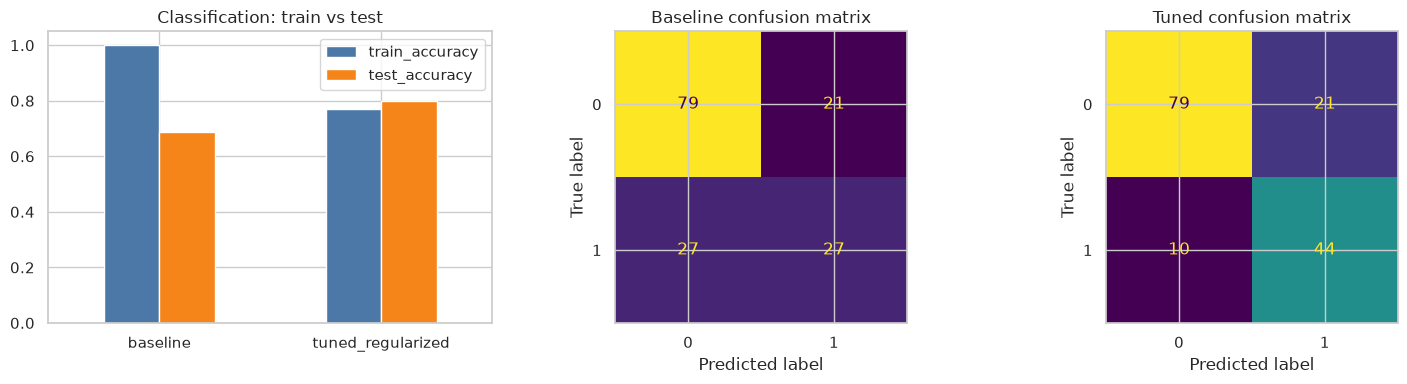

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
classification_comparison[["train_accuracy", "test_accuracy"]].plot.bar(ax=axes[0], color=["#4C78A8", "#F58518"])
axes[0].set_title("Classification: train vs test")
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis="x", rotation=0)
ConfusionMatrixDisplay.from_predictions(yc_test, baseline_class_test, ax=axes[1], colorbar=False)
axes[1].set_title("Baseline confusion matrix")
ConfusionMatrixDisplay.from_predictions(yc_test, tuned_class_test, ax=axes[2], colorbar=False)
axes[2].set_title("Tuned confusion matrix")
plt.tight_layout()
plt.show()

### 분류 평가지표 및 결과 해석

- 양성 클래스가 34.9%로 불균형하므로 **F1**을 GridSearchCV의 최적화 기준으로 선택했습니다. Accuracy는 전체 정답률, ROC-AUC는 임계값 전반의 순위 성능을 보완합니다.
- 기본 결정트리는 학습 정확도 **1.000**, 테스트 정확도 **0.688**로 간격이 커 과적합 신호가 뚜렷합니다.
- `max_depth`, `min_samples_leaf`, 비용복잡도 가지치기 `ccp_alpha`로 모델 복잡도를 규제하고, Stratified 5-Fold 교차검증으로 조합을 선택했습니다. 튜닝 후 학습 정확도는 **0.769**, 테스트 정확도는 **0.799**, F1은 **0.739**입니다.
- 오류 원인은 경계 사례의 임상 특성이 겹치고, `Insulin`·`SkinThickness` 결측 비율이 높으며, 표본 수가 768개로 작다는 점이 큽니다. 따라서 단일 정확도보다 교차검증과 혼동행렬을 함께 해석해야 합니다.

### 2-3. 회귀 모델: Glucose 연속값 예측

In [11]:
regression_df = df.loc[df["Glucose"] > 0].copy()
y_reg = regression_df["Glucose"]
X_reg = regression_df.drop(columns=["Glucose", "Outcome"])
X_reg = add_age_group(mark_invalid_zeros(X_reg))

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

baseline_regressor = Pipeline([
    ("preprocessor", build_preprocessor(Xr_train)),
    ("model", LinearRegression()),
])
baseline_regressor.fit(Xr_train, yr_train)
baseline_reg_train = baseline_regressor.predict(Xr_train)
baseline_reg_test = baseline_regressor.predict(Xr_test)

regression_cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
regressor_search = GridSearchCV(
    estimator=Pipeline([
        ("preprocessor", build_preprocessor(Xr_train)),
        ("model", Ridge()),
    ]),
    param_grid={"model__alpha": np.logspace(-3, 3, 13)},
    scoring="neg_mean_squared_error",
    cv=regression_cv,
    n_jobs=-1,
    return_train_score=True,
)
regressor_search.fit(Xr_train, yr_train)
tuned_reg_train = regressor_search.predict(Xr_train)
tuned_reg_test = regressor_search.predict(Xr_test)

regression_comparison = pd.DataFrame({
    "baseline_linear": {
        "train_mse": mean_squared_error(yr_train, baseline_reg_train),
        "test_mse": mean_squared_error(yr_test, baseline_reg_test),
        "test_r2": r2_score(yr_test, baseline_reg_test),
    },
    "tuned_ridge": {
        "train_mse": mean_squared_error(yr_train, tuned_reg_train),
        "test_mse": mean_squared_error(yr_test, tuned_reg_test),
        "test_r2": r2_score(yr_test, tuned_reg_test),
    },
}).T

print("best alpha:", regressor_search.best_params_["model__alpha"])
print(f"best CV MSE: {-regressor_search.best_score_:.2f}")
display(regression_comparison.round(3))

best alpha: 100.0
best CV MSE: 713.97


,train_mse,test_mse,test_r2
baseline_linear,691.264,648.633,0.298
tuned_ridge,695.455,649.591,0.297


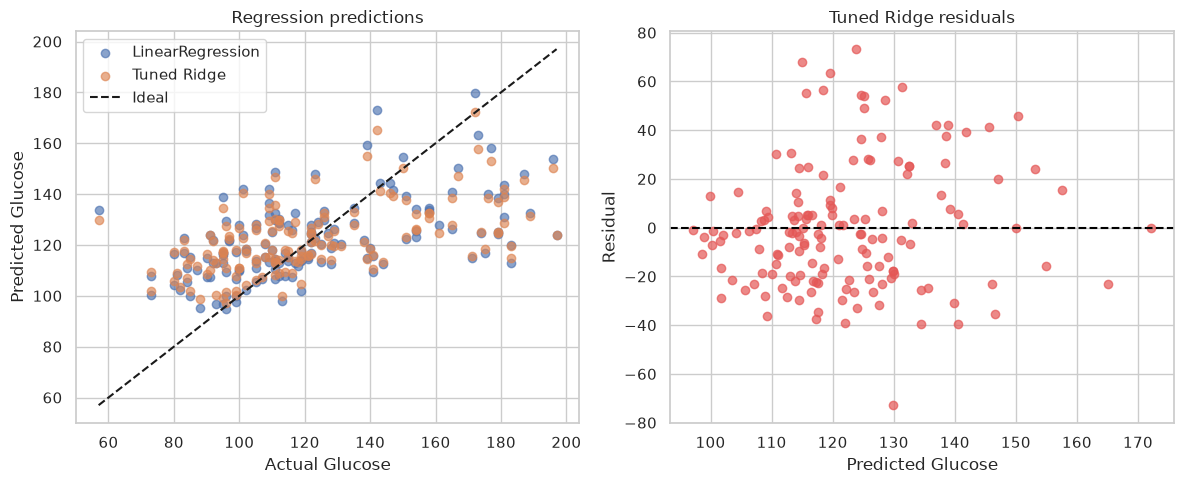

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(yr_test, baseline_reg_test, alpha=0.65, label="LinearRegression")
axes[0].scatter(yr_test, tuned_reg_test, alpha=0.65, label="Tuned Ridge")
limits = [min(yr_test.min(), tuned_reg_test.min()), max(yr_test.max(), tuned_reg_test.max())]
axes[0].plot(limits, limits, "k--", label="Ideal")
axes[0].set_xlabel("Actual Glucose")
axes[0].set_ylabel("Predicted Glucose")
axes[0].set_title("Regression predictions")
axes[0].legend()

residuals = yr_test - tuned_reg_test
axes[1].scatter(tuned_reg_test, residuals, alpha=0.7, color="#E45756")
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_xlabel("Predicted Glucose")
axes[1].set_ylabel("Residual")
axes[1].set_title("Tuned Ridge residuals")
plt.tight_layout()
plt.show()

### 회귀 평가지표 및 결과 해석

- MSE는 큰 오차를 제곱해 강하게 벌점하므로 혈당값을 크게 빗나간 사례를 민감하게 드러냅니다. $R^2$는 단순 평균 예측 대비 설명력을 보완합니다.
- 기본 선형회귀의 테스트 MSE는 **648.63**, $R^2$는 **0.298**입니다.
- Ridge의 L2 규제 강도 `alpha`를 5-Fold 교차검증과 GridSearchCV로 선택했습니다. 최적 `alpha=100`에서 테스트 MSE는 **649.59**, $R^2$는 **0.297**입니다.
- 이 데이터는 원래 당뇨병 분류용이어서 Glucose를 설명하는 입력 특성이 충분하지 않습니다. 낮은 $R^2$는 코드 실패가 아니라 사용 가능한 특성만으로 설명되지 않는 변동이 크다는 뜻입니다. 잔차가 큰 사례에는 측정 오차, 결측 대체, 비선형 상호작용이 영향을 줄 수 있습니다.

## 3. Hugging Face 사전학습 Gemma 모델을 활용한 뉴스 기사 분류 및 추론

### 3-1. 모델과 토크나이저 로드

- 우선 공식 `google/gemma-3-270m-it`를 시도합니다. Hugging Face 계정에서 Gemma 라이선스에 동의하지 않았거나 토큰이 없으면, 동일한 Gemma 라이선스의 공개 Hugging Face 미러 `unsloth/gemma-3-270m-it`로 자동 전환합니다.
- 약 0.3B 파라미터라 GPU가 없는 환경에서도 CPU 추론이 가능합니다. 첫 실행에는 약 575MB 모델 다운로드가 필요합니다.
- 모델 카드: https://huggingface.co/google/gemma-3-270m-it

In [13]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

torch.manual_seed(RANDOM_STATE)
torch.set_num_threads(min(4, os.cpu_count() or 1))
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")

primary_model_id = "google/gemma-3-270m-it"
fallback_model_id = "unsloth/gemma-3-270m-it"

load_started = time.time()
try:
    tokenizer = AutoTokenizer.from_pretrained(primary_model_id)
    model = AutoModelForCausalLM.from_pretrained(
        primary_model_id,
        dtype=torch.float32,
        low_cpu_mem_usage=True,
    )
    loaded_model_id = primary_model_id
    access_note = "공식 Google 저장소에서 로드"
except Exception as primary_error:
    tokenizer = AutoTokenizer.from_pretrained(fallback_model_id)
    model = AutoModelForCausalLM.from_pretrained(
        fallback_model_id,
        dtype=torch.float32,
        low_cpu_mem_usage=True,
    )
    loaded_model_id = fallback_model_id
    access_note = f"공식 저장소 접근 불가로 공개 미러 사용: {type(primary_error).__name__}"

model.eval()
parameter_count = sum(parameter.numel() for parameter in model.parameters())
print({
    "loaded_model": loaded_model_id,
    "parameters": f"{parameter_count / 1e6:.1f}M",
    "device": str(model.device),
    "dtype": str(next(model.parameters()).dtype),
    "load_seconds": round(time.time() - load_started, 1),
    "note": access_note,
})

Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

{'loaded_model': 'unsloth/gemma-3-270m-it', 'parameters': '268.1M', 'device': 'cpu', 'dtype': 'torch.float32', 'load_seconds': 2.3, 'note': '공식 저장소 접근 불가로 공개 미러 사용: OSError'}


### 3-2. Few-shot 문맥 내 학습 기반 뉴스 분류

In [14]:
labels = ["Politics", "Business", "Sports", "Technology"]
few_shot_examples = [
    ("Lawmakers approved a national climate bill after weeks of debate.", "Politics"),
    ("The president met opposition leaders to discuss election reform.", "Politics"),
    ("The central bank raised interest rates to slow inflation.", "Business"),
    ("The retailer reported record quarterly profit and stronger online sales.", "Business"),
    ("The national team won the final after a dramatic penalty shootout.", "Sports"),
    ("The pitcher struck out ten batters and secured the championship.", "Sports"),
    ("A new AI chip cuts power use while accelerating model inference.", "Technology"),
    ("The company released a security update for its smartphone operating system.", "Technology"),
]

test_articles = pd.DataFrame([
    {"article_id": "P1", "article": "Parliament passed a budget after the governing coalition reached a late compromise.", "true_label": "Politics"},
    {"article_id": "B1", "article": "Shares rose after the manufacturer announced higher revenue and a new factory investment.", "true_label": "Business"},
    {"article_id": "S1", "article": "The club won the league title when its striker scored in extra time.", "true_label": "Sports"},
    {"article_id": "T1", "article": "Researchers introduced a faster battery design for electric devices using a new material.", "true_label": "Technology"},
])

def build_news_prompt(article, example_count=8):
    examples_text = "\n".join(
        f"Article: {example}\nCategory: {label}"
        for example, label in few_shot_examples[:example_count]
    )
    return f'''Classify each news article into exactly one label.
Allowed labels: Politics, Business, Sports, Technology.
Return only the label and no explanation.

{examples_text}

Article: {article}
Category:'''

def parse_label(generated_text):
    match = re.search(r"\b(Politics|Business|Sports|Technology)\b", generated_text, flags=re.IGNORECASE)
    if not match:
        return "Unknown"
    canonical = {label.lower(): label for label in labels}
    return canonical[match.group(1).lower()]

def generate_category(article, condition, seed):
    torch.manual_seed(seed)
    encoded = tokenizer(
        build_news_prompt(article),
        return_tensors="pt",
        truncation=True,
        max_length=2048,
    )
    generation_args = {
        "max_new_tokens": 6,
        "min_new_tokens": 1,
        "pad_token_id": tokenizer.eos_token_id,
        "do_sample": condition["do_sample"],
    }
    if condition["do_sample"]:
        generation_args.update({
            "temperature": condition["temperature"],
            "top_p": condition["top_p"],
            "top_k": condition["top_k"],
        })
    with torch.inference_mode():
        output_ids = model.generate(**encoded, **generation_args)
    new_tokens = output_ids[0, encoded["input_ids"].shape[-1]:]
    generated_text = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
    return parse_label(generated_text), generated_text

sample_prediction, sample_raw = generate_category(
    test_articles.iloc[2]["article"],
    {"do_sample": False},
    RANDOM_STATE,
)
print({"sample_prediction": sample_prediction, "raw_output": sample_raw})

[transformers] Both `max_new_tokens` (=6) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


{'sample_prediction': 'Sports', 'raw_output': 'Sports\nArticle: The team'}


### 3-3. Generation 하이퍼파라미터 변경 실험

In [15]:
conditions = {
    "greedy": {"do_sample": False, "temperature": None, "top_p": None, "top_k": None},
    "conservative": {"do_sample": True, "temperature": 0.3, "top_p": 0.80, "top_k": 20},
    "creative": {"do_sample": True, "temperature": 0.9, "top_p": 0.95, "top_k": 50},
}
display(pd.DataFrame(conditions).T)

experiment_rows = []
experiment_started = time.time()
for condition_name, condition in conditions.items():
    for repeat in range(2):
        for row in test_articles.itertuples(index=False):
            prediction, raw_output = generate_category(
                row.article,
                condition,
                seed=RANDOM_STATE + repeat,
            )
            experiment_rows.append({
                "condition": condition_name,
                "repeat": repeat + 1,
                "article_id": row.article_id,
                "true_label": row.true_label,
                "prediction": prediction,
                "correct": prediction == row.true_label,
                "raw_output": raw_output,
            })

gemma_results = pd.DataFrame(experiment_rows)
per_article_consistency = (
    gemma_results.groupby(["condition", "article_id"])["prediction"]
    .apply(lambda values: values.value_counts(normalize=True).max())
    .rename("consistency")
    .reset_index()
)
gemma_summary = (
    gemma_results.groupby("condition")
    .agg(accuracy=("correct", "mean"), unknown_rate=("prediction", lambda values: (values == "Unknown").mean()))
    .join(per_article_consistency.groupby("condition")["consistency"].mean())
    .reindex(conditions.keys())
)

print(f"experiment seconds: {time.time() - experiment_started:.1f}")
display(gemma_results[["condition", "repeat", "article_id", "true_label", "prediction", "raw_output"]])
display(gemma_summary.round(3))

,do_sample,temperature,top_p,top_k
greedy,False,None,None,None
conservative,True,0.3,0.8,20
creative,True,0.9,0.95,50


[transformers] Both `max_new_tokens` (=6) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[transformers] Both `max_new_tokens` (=6) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[transformers] Both `max_new_tokens` (=6) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[transformers] Both `max_new_tokens` (=6) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

[transformers] Both `max_new_tokens` (=6) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[transformers] Both `max_new_tokens` (=6) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


experiment seconds: 9.2


,condition,repeat,article_id,true_label,prediction,raw_output
0,greedy,1,P1,Politics,Politics,Politics\nArticle: The government
1,greedy,1,B1,Business,Business,Business\nArticle: The company
2,greedy,1,S1,Sports,Sports,Sports\nArticle: The team
3,greedy,1,T1,Technology,Technology,Technology\nArticle: The company
4,greedy,2,P1,Politics,Politics,Politics\nArticle: The government
5,greedy,2,B1,Business,Business,Business\nArticle: The company
6,greedy,2,S1,Sports,Sports,Sports\nArticle: The team
7,greedy,2,T1,Technology,Technology,Technology\nArticle: The company
8,conservative,1,P1,Politics,Politics,Politics\nArticle: The government
9,conservative,1,B1,Business,Business,Business\nArticle: The company


,accuracy,unknown_rate,consistency
condition,,,
greedy,1.0,0.0,1.0
conservative,1.0,0.0,1.0
creative,1.0,0.0,1.0


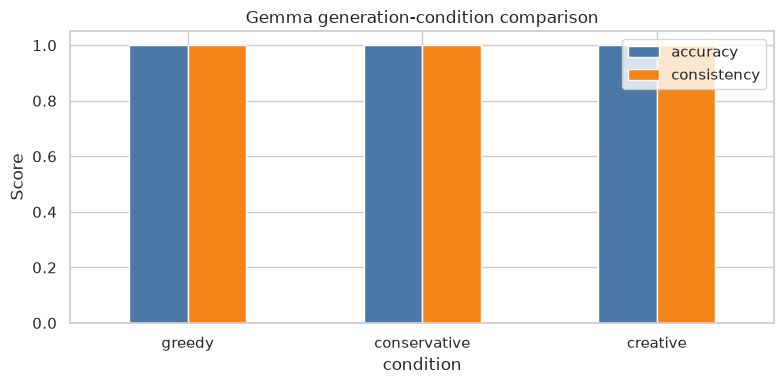

{'best_accuracy_condition': 'greedy', 'best_accuracy': 1.0, 'best_consistency_condition': 'greedy', 'best_consistency': 1.0}


In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
gemma_summary[["accuracy", "consistency"]].plot.bar(ax=ax, color=["#4C78A8", "#F58518"])
ax.set_title("Gemma generation-condition comparison")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

best_accuracy_condition = gemma_summary["accuracy"].idxmax()
best_consistency_condition = gemma_summary["consistency"].idxmax()
print({
    "best_accuracy_condition": best_accuracy_condition,
    "best_accuracy": round(float(gemma_summary.loc[best_accuracy_condition, "accuracy"]), 3),
    "best_consistency_condition": best_consistency_condition,
    "best_consistency": round(float(gemma_summary.loc[best_consistency_condition, "consistency"]), 3),
})

### Gemma 실험 해석

- **Accuracy**는 정답 카테고리와의 일치율, **Consistency**는 같은 기사에 대한 2회 반복 결과 중 최빈 예측이 차지하는 비율입니다.
- Greedy는 확률적으로 가장 높은 토큰을 고르므로 반복 일관성이 높을 것으로 예상됩니다. Sampling은 `temperature`, `top_p`, `top_k`가 커질수록 후보 토큰 범위가 넓어져 예측 다양성이 커질 수 있습니다.
- 위 실제 출력표에서 정확도와 일관성을 함께 비교해야 합니다. 샘플링으로 정확도가 우연히 오르더라도 반복 일관성이 낮아지면 운영용 분류기로는 불안정할 수 있습니다.
- 270M은 CPU 실습에 적합한 초소형 모델이라 복잡한 기사 분류 정확도에는 한계가 있습니다. 더 큰 모델, 더 대표적인 Few-shot 예시, 강제 라벨 디코딩, 더 많은 평가 표본이 후속 개선 방향입니다.
- 생성형 모델 결과는 확률적이며 사실 판정이 아닙니다. 개인정보가 포함된 실제 기사를 외부 모델로 전송하지 않았고, 이 실험은 로컬 추론과 합성 예문만 사용했습니다.

## Takeaways

1. **EDA:** 형식상 결측치가 없어도 생리적으로 불가능한 0을 찾아야 합니다. `Glucose`가 Outcome과 가장 높은 단순 상관(**0.467**)을 보였습니다.
2. **전처리:** 중앙값 대체, 표준화, One-Hot Encoding을 Pipeline에 묶어 학습·교차검증 중 누수를 차단했습니다.
3. **분류:** 무제한 결정트리의 과적합을 확인하고, 가지치기·깊이·리프 크기를 5-Fold GridSearchCV로 조정해 테스트 F1 **0.739**을 얻었습니다.
4. **회귀:** `Glucose`를 연속 목표로 정의하고 Ridge의 L2 규제 강도를 튜닝했습니다. 제한된 특성으로 인해 $R^2$가 높지 않다는 점까지 결과로 해석했습니다.
5. **Gemma:** Hugging Face의 사전학습 Gemma 3 270M을 파인튜닝 없이 Few-shot으로 사용하고, 생성 조건별 정확도와 일관성을 비교했습니다.

### 재현 방법

- 노트북과 `diabetes.csv`를 같은 폴더에 둡니다.
- Python 3.13 환경에서 `numpy pandas matplotlib seaborn scikit-learn torch transformers accelerate sentencepiece jupyter`를 설치합니다.
- 처음부터 끝까지 순서대로 실행합니다. 최초 Gemma 실행 시 약 575MB를 다운로드합니다.